# Scores across conditions

`build_scores.py` scores every condition from the move logs and returns one long
DataFrame, one row per participant-round. It also writes `scores_<condition>.csv` per
condition and `scores_all.csv` combined.

Two things it fixes that a plain `score_from_logs.py --dir` cannot:

- **Conditions that share a directory.** Phase 2's vanilla, v2 and v9 arms are told apart
  by `intervention.json`, not by folder.
- **The `ai` flag.** Every copy of `score_from_logs.py` hardcodes R1 as assisted, but the
  two baseline studies played R1 with no assistant at all.

**No exclusions are baked in.** The columns that define the population are carried instead
— `carryover`, `reached_demographics`, `prompt_rule`, `prompt_mean_score`, `prompt_passed`,
`effort_median` — so each analysis applies its own. Filtering
`~carryover & reached_demographics` reproduces the phase-2 analysis set.

In [49]:
import glob

# Adopter no-AI baseline: Baseline dir, /Users/siyanli/Documents/CITRUS/game_user_study_baseline_othello, under recordings-download-adopters
# Adopters vanilla AI: /Users/siyanli/Documents/CITRUS/game_user_study_phase_othello , recordings-download
# Non-adopters no-AI baseline: /Users/siyanli/Documents/CITRUS/game_user_study_baseline_othello, under recordings-download
# Non-adopters vanilla AI: /Users/siyanli/Documents/CITRUS/game_user_study_phase_2 , vanilla (having no intervention.json but demographics.json)
# Non-adopters intervention v2: /Users/siyanli/Documents/CITRUS/game_user_study_phase_2 , has intervention.json and demographics.json, and intervention variant is v2
# Non-adopters intervention v9: /Users/siyanli/Documents/CITRUS/game_user_study_phase_2 , has intervention.json and demographics.json, and intervention variant is v9
# Non-adopters intervention johnny: /Users/siyanli/Documents/CITRUS/game_user_study_intervention_iter/recordings-download
# Non-adopters intervention modelled-ta: /Users/siyanli/Documents/CITRUS/game_user_study_intervention_iter/recordings-modelled-ta
# Non-adopters intervention esr: /Users/siyanli/Documents/CITRUS/game_user_study_intervention_iter/recordings-esr

In [50]:
import importlib

import build_scores
build = importlib.reload(build_scores).build   # the kernel caches this module, and a stale
                                              # copy rewrites the CSVs from whatever
                                              # condition list it was imported with

# write=True also refreshes the per-condition CSVs and scores_all.csv
df = build()
df.shape


condition                 population     participants  R1 rounds  both solo rounds
baseline_adopters         adopters                102        102               100
vanilla_adopters          adopters                125        124               111
baseline_non_adopters     non-adopters             51         51                50
vanilla_non_adopters      non-adopters             41         41                38
intervention_v2           non-adopters             28         28                25
intervention_v9           non-adopters             17         17                15
intervention_johnny       non-adopters             22         22                 0
intervention_modelled_ta  non-adopters             16         16                 0
intervention_esr          non-adopters             15         15                 0
3arm_vanilla              non-adopters             17         17                17   -> pooled into vanilla_non_adopters
3arm_johnny               non-adopters           

(1186, 53)

## R1 (assisted round) by condition

The three newest interventions ran assisted-only, so they have **no R2/R3 rows** — any
transfer comparison covers the six older conditions only.

In [51]:
r1 = df[(df["round"] == "R1") & ~df.carryover & df.reached_demographics].copy()
r1["optimal_pct"] = 100 * r1.score / r1.decisions

(r1.groupby(["population", "condition"])
   .agg(n=("pid", "nunique"), optimal_pct=("optimal_pct", "mean"),
        margin_mean=("margin", "mean"), margin_median=("margin", "median"),
        solved=("solved", "sum"), ai_turns=("ai_turns", "mean"))
   .round(1))

n  optimal_pct  margin_mean  \
population   condition                                                 
adopters     baseline_adopters         100         43.2        -21.0   
             vanilla_adopters          111         69.6         -8.4   
non-adopters baseline_non_adopters      50         35.4        -22.2   
             intervention_esr           14         67.1        -13.8   
             intervention_johnny        34         75.5         -4.4   
             intervention_modelled_ta   15         61.3        -12.4   
             intervention_v2            16         72.2         -7.5   
             intervention_v9            15         71.1         -4.5   
             vanilla_non_adopters       46         69.4         -8.0   

                                       margin_median  solved  ai_turns  
population   condition                                                  
adopters     baseline_adopters                 -22.0       0       0.0  
             vanilla_adopters                  -18.0      21       5.5  
non-adopters baseline_non_adopters             -22.0       0       0.0  
             intervention_esr                  -18.0       1       5.5  
             intervention_johnny                -4.0      11       5.4  
             intervention_modelled_ta          -20.0       2       5.8  
             intervention_v2                   -14.0       3       5.2  
             intervention_v9                   -18.0       6       6.4  
             vanilla_non_adopters              -18.0       8       5.5

## Transfer block — summed margin over the two unassisted rounds

Only the conditions that ran solo rounds appear; the three newest interventions ran assisted-only.


In [52]:
# Total margin across the two unassisted rounds, one value per participant.
# Only participants who completed BOTH are counted -- summing over one round would put them
# on a different scale. `margin` is None for a round that timed out with squares still
# empty (a position, not a result), so those participants drop out here.
solo = df[df.transfer & ~df.carryover & df.reached_demographics]

solo_margin = (solo.groupby(["population", "condition", "pid"])["margin"]
                   .agg(["sum", "count"])
                   .query("count == 2")["sum"]
                   .rename("solo_margin")
                   .reset_index())

(solo_margin.groupby(["population", "condition"])["solo_margin"]
            .agg(n="size", mean="mean", median="median", sd="std",
                 min="min", max="max")
            .round(2))

n   mean  median     sd   min   max
population   condition                                                   
adopters     baseline_adopters      100 -15.30   -15.0  12.49 -40.0  16.0
             vanilla_adopters       108 -13.50   -14.0  11.52 -34.0  16.0
non-adopters baseline_non_adopters   50 -18.36   -21.0  11.71 -38.0  16.0
             intervention_johnny     13 -14.31   -14.0  12.98 -32.0  16.0
             intervention_v2         16 -18.62   -20.0  10.24 -36.0   4.0
             intervention_v9         15 -14.53   -14.0  12.29 -38.0   6.0
             vanilla_non_adopters    45 -13.87   -16.0  15.56 -40.0  16.0

## Margin distributions

One dot per participant, identical values stacked, so the **bimodality** is visible: people
who finish the position land at the ceiling (+18 in R1, +16 across both solo rounds) and the
rest cluster near −20. That is why a condition mean is close to a re-encoding of its solve
rate, and why the median tick sits where it does.

Colour marks whether the CONDITION had an assisted round — in the right-hand panel nobody
has an assistant, so the colours there identify the condition, not the round.

## Split into one DataFrame per condition

In [53]:
import pandas as pd

# One DataFrame per condition, each already filtered to the analysis set
# (fresh recruits who reached the demographics page). Everything below works from these
# rather than from `df`, so a condition can be inspected or swapped on its own.
ORDER = ["baseline_adopters", "vanilla_adopters",
         "baseline_non_adopters", "vanilla_non_adopters",
         "intervention_v2", "intervention_v9",
         "intervention_johnny", "intervention_modelled_ta", "intervention_esr"]

analysed = df[~df.carryover & df.reached_demographics]
dfs = {c: analysed[analysed.condition == c].copy() for c in ORDER}

# Named handles for poking at one condition directly.
df_baseline_adopters     = dfs["baseline_adopters"]
df_vanilla_adopters      = dfs["vanilla_adopters"]
df_baseline_non_adopters = dfs["baseline_non_adopters"]
df_vanilla_non_adopters  = dfs["vanilla_non_adopters"]
df_v2                    = dfs["intervention_v2"]
df_v9                    = dfs["intervention_v9"]
df_johnny                = dfs["intervention_johnny"]
df_modelled_ta           = dfs["intervention_modelled_ta"]
df_esr                   = dfs["intervention_esr"]

# R1 row and summed solo margin, per condition.
r1s = {c: d[d["round"] == "R1"] for c, d in dfs.items()}
solos = {c: (d[d.transfer].groupby("pid").margin.agg(["sum", "size"])
              .query("size == 2")["sum"])
         for c, d in dfs.items()}

pd.DataFrame({"participants": {c: d.pid.nunique() for c, d in dfs.items()},
              "R1 rows": {c: len(v) for c, v in r1s.items()},
              "both solo rounds": {c: len(v) for c, v in solos.items()}}).loc[ORDER]

,participants,R1 rows,both solo rounds
baseline_adopters,100,100,100
vanilla_adopters,112,111,111
baseline_non_adopters,50,50,50
vanilla_non_adopters,46,46,46
intervention_v2,16,16,16
intervention_v9,15,15,15
intervention_johnny,34,34,13
intervention_modelled_ta,15,15,0
intervention_esr,14,14,0


## Sensitivity: dropping johnny's late batch


In [54]:
# --- explicit exclusion: johnny's late batch -------------------------------------
# The 5 johnny participants who consented at ~20:00-21:00 UTC on 2026-08-20 are dropped,
# on the grounds that they were recruited late in the day and may be a different slice of
# the pool from the 01:00 batch.
#
# Scoped on `batch`, not on `condition`: intervention_johnny now also holds the 3-arm
# batch (consented 2026-08-21), and an open-ended cut at 2026-08-20T18 would drop all 13
# of those as well.
#
# STATE THIS IF IT IS REPORTED. The exclusion is correlated with the outcome -- this is the
# batch that pulled johnny's R1 optimal rate from 75.4 to 71.2 -- and it is not applied
# symmetrically: every other condition also sits in one narrow recruitment window
# (modelled_TA is entirely hour 02, v9 is one day, the baselines span other hours) and none
# of those are dropped. Keep DROP_LATE_JOHNNY = False as the primary analysis and use
# True only as a stated sensitivity check.
DROP_LATE_JOHNNY = True

def late_johnny(d):
    return ((d.batch == "intervention_johnny")
            & (d.consented_at.fillna("") >= "2026-08-20T18"))

print(f"late johnny batch: {df.loc[late_johnny(df), 'pid'].nunique()} participants")

analysed = df[~df.carryover & df.reached_demographics]
if DROP_LATE_JOHNNY:
    analysed = analysed[~late_johnny(analysed)]

r1x = analysed[analysed["round"] == "R1"].copy()
r1x["optimal_pct"] = 100 * r1x.score / r1x.decisions

both = []
for label, keep in (("with late batch", False), ("without late batch", True)):
    a = df[~df.carryover & df.reached_demographics]
    if keep:
        a = a[~late_johnny(a)]
    g = a[(a["round"] == "R1") & (a.condition == "intervention_johnny")]
    both.append({"version": label, "n": len(g),
                 "R1 optimal %": round(100 * g.score.sum() / g.decisions.sum(), 1),
                 "R1 optimal % (mean of persons)": round((100 * g.score / g.decisions).mean(), 1),
                 "margin mean": round(g.margin.mean(), 1),
                 "solved": f"{int(g.solved.sum())}/{len(g)}"})


late johnny batch: 6 participants


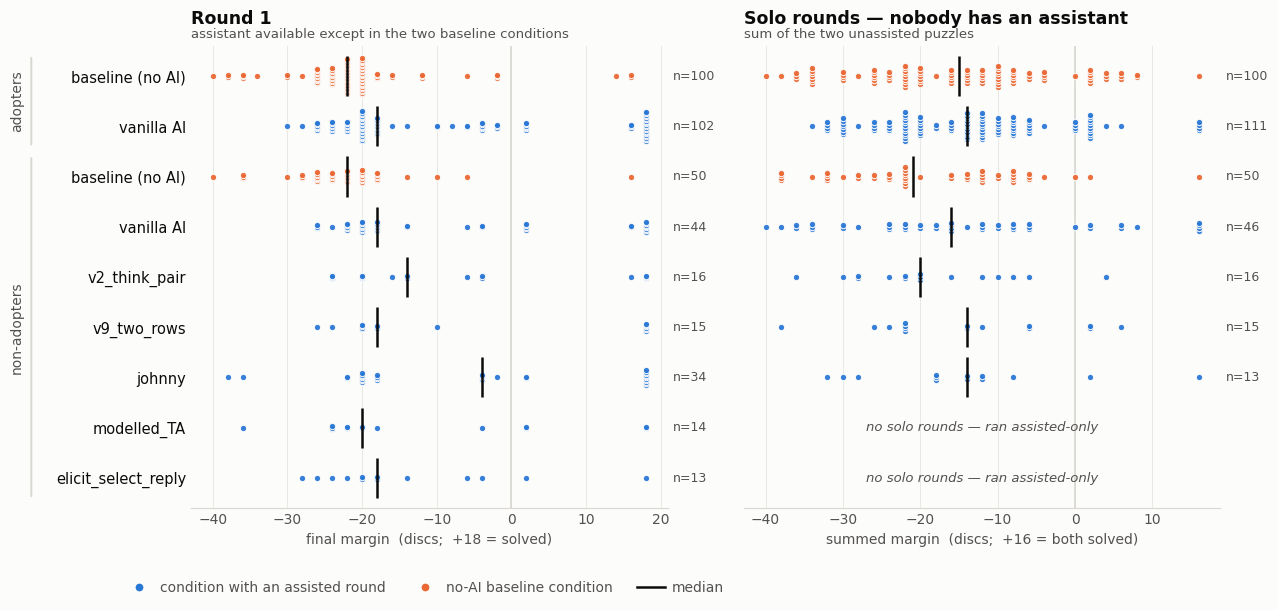

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Slots 1-2 of the reference categorical palette. Identity is carried by the y-axis, so
# colour encodes only one thing: whether the CONDITION included an assisted round.
AI_ON, AI_OFF = "#2a78d6", "#eb6834"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#d8d7d2", "#fcfcfb"

keep = ~df.carryover & df.reached_demographics
ORDER = ["baseline_adopters", "vanilla_adopters",
         "baseline_non_adopters", "vanilla_non_adopters",
         "intervention_v2", "intervention_v9",
         "intervention_johnny", "intervention_modelled_ta", "intervention_esr"]
LABEL = {"baseline_adopters": "baseline (no AI)", "vanilla_adopters": "vanilla AI",
         "baseline_non_adopters": "baseline (no AI)", "vanilla_non_adopters": "vanilla AI",
         "intervention_v2": "v2_think_pair", "intervention_v9": "v9_two_rows",
         "intervention_johnny": "johnny", "intervention_modelled_ta": "modelled_TA",
         "intervention_esr": "elicit_select_reply"}

r1 = df[keep & (df["round"] == "R1")]
solo = df[keep & df.transfer]
ss = (solo.groupby(["condition", "pid"]).margin.agg(["sum", "size"])
          .query("size == 2")["sum"].reset_index())
HAS_AI = {c: bool(r1[r1.condition == c].ai.iloc[0]) for c in ORDER
          if len(r1[r1.condition == c])}

R1V = {c: r1[r1.condition == c].margin.dropna().tolist() for c in ORDER}
SOV = {c: ss[ss.condition == c]["sum"].tolist() for c in ORDER}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 6.6), sharey=True,
                         gridspec_kw={"wspace": 0.16})
fig.patch.set_facecolor(SURF)


def strip(ax, data, title, note, xlabel):
    # One step size for the whole panel, sized so the tallest column of identical
    # values still fits inside its row. Stacks are CENTRED, so they cannot climb into
    # the row above -- the bug in the first draft.
    tallest = max((max(Counter(v).values()) for v in data.values() if v), default=1)
    step = min(0.052, 0.74 / max(tallest, 1))
    for i, cond in enumerate(ORDER):
        y0, vals = -i, data.get(cond)
        if not vals:
            ax.text(0.5, y0, "no solo rounds — ran assisted-only", va="center",
                    ha="center", color=INK2, fontsize=9.5, style="italic",
                    transform=ax.get_yaxis_transform(which="grid"))
            continue
        c = AI_ON if HAS_AI.get(cond) else AI_OFF
        counts = Counter(vals)
        for v in sorted(counts):
            n = counts[v]
            for k in range(n):
                ax.plot(v, y0 + (k - (n - 1) / 2) * step, "o", ms=4.6, color=c,
                        mec=SURF, mew=0.8, alpha=.95, zorder=3)
        med = float(np.median(vals))
        ax.plot([med, med], [y0 - 0.40, y0 + 0.40], color=INK, lw=1.8, zorder=4,
                solid_capstyle="butt")
        # n outside the axes, so it can never sit on top of a mark
        ax.annotate(f"n={len(vals)}", xy=(1.012, y0), xycoords=("axes fraction", "data"),
                    va="center", ha="left", color=INK2, fontsize=9, annotation_clip=False)
    ax.axvline(0, color=GRID, lw=1.2, zorder=1)
    ax.set_title(title, color=INK, fontsize=12.5, loc="left", pad=16, fontweight="600")
    ax.text(0, 1.012, note, transform=ax.transAxes, color=INK2, fontsize=9.5, va="bottom")
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_facecolor(SURF)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK2, length=0, labelsize=10)
    ax.grid(axis="x", color=GRID, lw=.7, alpha=.55, zorder=0)
    ax.set_axisbelow(True)


strip(axes[0], R1V, "Round 1",
      "assistant available except in the two baseline conditions",
      "final margin  (discs;  +18 = solved)")
strip(axes[1], SOV, "Solo rounds — nobody has an assistant",
      "sum of the two unassisted puzzles",
      "summed margin  (discs;  +16 = both solved)")

axes[0].set_yticks([-i for i in range(len(ORDER))], [LABEL[c] for c in ORDER], fontsize=10.5)
for t in axes[0].get_yticklabels():
    t.set_color(INK)
axes[0].set_ylim(-len(ORDER) + 0.4, 0.6)

for lab, i0, i1 in (("adopters", 0, 1), ("non-adopters", 2, 8)):
    axes[0].annotate("", xy=(-0.335, -i0 + 0.42), xytext=(-0.335, -i1 - 0.42),
                     xycoords=("axes fraction", "data"),
                     arrowprops=dict(arrowstyle="-", color=GRID, lw=1.4),
                     annotation_clip=False)
    axes[0].annotate(lab, xy=(-0.365, -(i0 + i1) / 2), xycoords=("axes fraction", "data"),
                     rotation=90, va="center", ha="center", color=INK2, fontsize=10,
                     annotation_clip=False)

h = [plt.Line2D([], [], marker="o", ls="", ms=6.5, color=AI_ON, mec=SURF, mew=.9),
     plt.Line2D([], [], marker="o", ls="", ms=6.5, color=AI_OFF, mec=SURF, mew=.9),
     plt.Line2D([], [], color=INK, lw=1.8)]
fig.legend(h, ["condition with an assisted round", "no-AI baseline condition", "median"],
           loc="lower left", bbox_to_anchor=(0.145, 0.005), ncol=3, frameon=False,
           fontsize=10, labelcolor=INK2, handletextpad=.5, columnspacing=1.8)
fig.subplots_adjust(left=0.20, right=0.925, top=0.855, bottom=0.155)
plt.show()


In [56]:
df_baseline_adopters.columns

Index(['condition', 'batch', 'population', 'pid', 'round', 'puzzle', 'ai',
       'transfer', 'form', 'variant', 'consented_at', 'pretask_at',
       'prompt_rule', 'prompt_mean_score', 'prompt_passed', 'carryover',
       'reached_demographics', 'effort_median', 'skill_rating', 'age',
       'education', 'genai_usage', 'gate_correct', 'gate_confidence',
       'ai_turns', 'end_reason', 'decisions', 'score', 'decisions_first_n',
       'score_first_n', 'kept_win_score', 'kept_win_first_n', 'opener_optimal',
       'disc_loss_total', 'disc_loss_per_decision', 'seconds', 'completed',
       'black_discs', 'white_discs', 'margin', 'won', 'moves', 'attempts',
       'solved', 'transfer_rounds', 'transfer_score', 'transfer_decisions',
       'transfer_rate', 'transfer_wins', 'transfer_solved', 'transfer_openers',
       'transfer_disc_loss', 'transfer_label'],
      dtype='str')

# Baseline adopters and baseline non-adopters are the same on R1, R2 (?), R3

In [57]:
from scipy.stats import mannwhitneyu
import numpy as np

for r in ["R1", "R2", "R3"]:
    curr_round_adopter = df_baseline_adopters.loc[df_baseline_adopters["round"] == r]["margin"].to_list()
    curr_round_non_adopter = df_baseline_non_adopters.loc[df_baseline_non_adopters["round"] == r]["margin"].to_list()
    print("EVALUATING:   ", r)
    print("\t Adopters:", np.mean(curr_round_adopter))
    print("\t Non-Adopters:", np.mean(curr_round_non_adopter))
    print(mannwhitneyu(curr_round_adopter, curr_round_non_adopter))

EVALUATING:    R1
	 Adopters: -20.96
	 Non-Adopters: -22.16
MannwhitneyuResult(statistic=np.float64(2668.0), pvalue=np.float64(0.49790952956643286))
EVALUATING:    R2
	 Adopters: -3.36
	 Non-Adopters: -6.32
MannwhitneyuResult(statistic=np.float64(2968.0), pvalue=np.float64(0.0567225579964558))
EVALUATING:    R3
	 Adopters: -11.94
	 Non-Adopters: -12.04
MannwhitneyuResult(statistic=np.float64(2503.5), pvalue=np.float64(0.9903625243426408))


# Vanilla Adopters are around the same as vanilla non-adopters

In [58]:
for r in ["R1", "R2", "R3"]:
    curr_round_adopter = df_vanilla_adopters.loc[df_vanilla_adopters["round"] == r]["margin"].dropna().to_list()
    curr_round_non_adopter = df_vanilla_non_adopters.loc[df_vanilla_non_adopters["round"] == r]["margin"].dropna().to_list()
    print("EVALUATING:   ", r)
    print("\t Adopters:", np.mean(curr_round_adopter), np.median(curr_round_adopter))
    print("\t Non-Adopters:", np.mean(curr_round_non_adopter), np.median(curr_round_non_adopter))
    print(mannwhitneyu(curr_round_adopter, curr_round_non_adopter))

EVALUATING:    R1
	 Adopters: -8.372549019607844 -18.0
	 Non-Adopters: -8.045454545454545 -18.0
MannwhitneyuResult(statistic=np.float64(2180.0), pvalue=np.float64(0.7843854192055169))
EVALUATING:    R2
	 Adopters: -3.2037037037037037 -2.0
	 Non-Adopters: -1.9130434782608696 -3.0
MannwhitneyuResult(statistic=np.float64(2420.0), pvalue=np.float64(0.7978979453639841))
EVALUATING:    R3
	 Adopters: -10.375 -10.0
	 Non-Adopters: -12.311111111111112 -12.0
MannwhitneyuResult(statistic=np.float64(2845.0), pvalue=np.float64(0.20215162834869527))


# Are Interventions producing better scores?

In [59]:
for labe, interv in [
    ("v2", df_v2),
    ("v9", df_v9),
    ("johnny", df_johnny),
    ("esr", df_esr),
    ("model", df_modelled_ta)]:
    print("Evaluating: ", labe)
    curr_round_vanilla = df_vanilla_non_adopters.loc[df_vanilla_non_adopters["round"] == "R1"]["margin"].dropna().to_list()
    curr_round_interv = interv.loc[interv["round"] == "R1"]["margin"].dropna().to_list()
    print("\t Vanilla:", np.mean(curr_round_vanilla), np.median(curr_round_vanilla), len(curr_round_vanilla))
    print("\t Intervention:", np.mean(curr_round_interv), np.median(curr_round_interv), len(curr_round_interv))
    print(mannwhitneyu(curr_round_vanilla, curr_round_interv))


Evaluating:  v2
	 Vanilla: -8.045454545454545 -18.0 44
	 Intervention: -7.5 -14.0 16
MannwhitneyuResult(statistic=np.float64(343.0), pvalue=np.float64(0.8861029089075174))
Evaluating:  v9
	 Vanilla: -8.045454545454545 -18.0 44
	 Intervention: -4.533333333333333 -18.0 15
MannwhitneyuResult(statistic=np.float64(296.0), pvalue=np.float64(0.5544423298732613))
Evaluating:  johnny
	 Vanilla: -8.045454545454545 -18.0 44
	 Intervention: -4.411764705882353 -4.0 34
MannwhitneyuResult(statistic=np.float64(638.0), pvalue=np.float64(0.2634448211947369))
Evaluating:  esr
	 Vanilla: -8.045454545454545 -18.0 44
	 Intervention: -13.846153846153847 -18.0 13
MannwhitneyuResult(statistic=np.float64(342.5), pvalue=np.float64(0.2829542627946988))
Evaluating:  model
	 Vanilla: -8.045454545454545 -18.0 44
	 Intervention: -12.428571428571429 -20.0 14
MannwhitneyuResult(statistic=np.float64(375.0), pvalue=np.float64(0.22298244211382068))


# Do Non-Adopters with AI transfer better?

In [60]:
# Total solo margin per participant (R2 + R3 summed) rather than the two rounds
# separately. Only participants who completed BOTH are counted -- summing over one round
# would put them on a different scale from everyone else.
def total_solo(d):
    s = (d.loc[d.transfer].groupby("pid")["margin"]
           .agg(["sum", "count"]))
    return s.loc[s["count"] == 2, "sum"]

curr_vanilla  = total_solo(df_vanilla_non_adopters).to_list()
curr_baseline = total_solo(df_baseline_non_adopters).to_list()

print("EVALUATING Non-Adopters:    total solo margin (R2+R3)")
print("\t Vanilla: ", np.mean(curr_vanilla), np.median(curr_vanilla), f"n={len(curr_vanilla)}")
print("\t Baseline:", np.mean(curr_baseline), np.median(curr_baseline), f"n={len(curr_baseline)}")
print(mannwhitneyu(curr_vanilla, curr_baseline))

EVALUATING Non-Adopters:    total solo margin (R2+R3)
	 Vanilla:  -13.866666666666667 -16.0 n=45
	 Baseline: -18.36 -21.0 n=50
MannwhitneyuResult(statistic=np.float64(1296.5), pvalue=np.float64(0.2015274354777573))
